# CastMe callback-prediction baseline

## 1. Introduction

CastMe is a synthetic experimental audition system designed to study how personal-data deletion-request structure affects forgetting, retained utility and computation. Each row is one audition submission, uniquely identified by `audition_id`. `audition_round` records ordered attempts for an actor-role pair; later rounds can represent callbacks, re-auditions or further takes. A callback means progressing to another casting stage, not necessarily receiving the final role.

Actors are performers, managers are representation or agency accounts, films are casting projects and roles belong to films. `audition_date` is audit metadata for retention analysis, while `withdrawal_requested` records a submission-level operational deletion request. These fields support realistic person-, submission-, provider-, project- and time-based experiments, but are never classifier inputs and do not establish legal or regulatory compliance.


## 2. Imports, Reproducibility and Configuration

### 2.1 Import Libraries

The notebook uses pandas and scikit-learn for data handling, PyTorch for the
MLP, and matplotlib for the required diagnostic figures.

In [1]:
# imports
from __future__ import annotations

import copy
import hashlib
import json
import platform
import random
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
from IPython.display import display
from pandas.api.types import is_numeric_dtype
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

### 2.2 Reproducibility and Device

The global seed and device are configured once; the five-seed helper resets only its local training state.

### 2.3 Model and Training Settings

These fixed settings are selected without test-set tuning.

The following configuration cell defines every global split, model, optimiser and early-stopping setting exactly once.

In [2]:
# initialisations
RANDOM_SEED = 42
TRAIN_PROPORTION = 0.70
VALIDATION_PROPORTION = 0.15
TEST_PROPORTION = 0.15
PREVIOUS_FIXED_THRESHOLD = 0.40
THRESHOLD_GRID = np.round(np.arange(0.10, 0.901, 0.01), 2)
ROBUSTNESS_SEEDS = [21, 42, 84, 126, 168]
BOOTSTRAP_SEED = 2025
BOOTSTRAP_RESAMPLES = 1_000
HIDDEN_LAYER_DIMS = (16, 8)
DROPOUT_PROBABILITY = 0.10
BATCH_SIZE = 64
LEARNING_RATE = 0.001
WEIGHT_DECAY = 0.0001
MAX_EPOCHS = 100
EARLY_STOPPING_PATIENCE = 12
EARLY_STOPPING_MIN_DELTA = 0.00001

# set seed
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")


In [3]:
# runtime versions
RUNTIME_VERSIONS = {
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "pytorch": torch.__version__,
}

# store model trainiing hyperparameters in a dictionary for easy access and logging
TRAINING_HYPERPARAMETERS = {
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "dropout_probability": DROPOUT_PROBABILITY,
    "maximum_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "early_stopping_min_delta": EARLY_STOPPING_MIN_DELTA,
    "loss_function": "BCEWithLogitsLoss",
    "optimizer": "AdamW",
}
print(f"Using device: {DEVICE}")
print(RUNTIME_VERSIONS)

Using device: mps
{'python': '3.12.13', 'pandas': '3.0.3', 'scikit_learn': '1.9.0', 'pytorch': '2.12.1'}


## 3. Load Dataset

A project-root search avoids depending on the notebook's launch directory. The
raw dataset is read without modification, and its SHA-256 hash is retained to
verify that model training does not alter it.

In [4]:
# find the main code folder
def locate_code_root(start_path: Path) -> Path:
    """Return the code directory that contains the approved CastMe CSV."""
    for candidate in [start_path, *start_path.parents]:
        raw_candidate = candidate / "data" / "raw" / "castme"
        nested_candidate = candidate / "code" / "data" / "raw" / "castme"
        if (raw_candidate / "castme_auditions.csv").is_file():
            return candidate
        if (nested_candidate / "castme_auditions.csv").is_file():
            return candidate / "code"
    raise FileNotFoundError("Could not locate code/data/raw/castme/castme_auditions.csv")

# calculate a unique hash for checking whether a file changes 
def sha256(path: Path) -> str:
    """Return the SHA-256 digest for a file without changing it."""
    return hashlib.sha256(path.read_bytes()).hexdigest()

# locatie and load the raw CastMe dataset
CODE_ROOT = locate_code_root(Path.cwd().resolve())
DATA_PATH = CODE_ROOT / "data" / "raw" / "castme" / "castme_auditions.csv"
df = pd.read_csv(DATA_PATH)
RAW_CSV_SHA256 = sha256(DATA_PATH)

#preview
display(df.head())
print(f"Raw file path: {DATA_PATH.relative_to(CODE_ROOT)}")
print(f"Dataframe shape: {df.shape}")
print(f"Raw CSV SHA-256: {RAW_CSV_SHA256}")

,audition_id,actor_id,manager_id,film_id,role_id,audition_round,audition_date,withdrawal_requested,experience_years,role_match_score,accent_match,availability_match,line_accuracy_score,special_skill_match,self_tape_quality_score,manager_rating,prior_collaboration,days_before_deadline,callback
0,AU000001,A001,M01,F01,RL0001,1,2023-07-25,False,4.1,0.180468,0,0,0.721376,0,0.162849,0.504453,0,14,0
1,AU000002,A001,M01,F02,RL0025,1,2024-02-22,False,4.1,0.373595,1,0,0.481558,1,0.790987,0.461481,1,7,0
2,AU000003,A001,M01,F03,RL0049,1,2025-05-12,False,4.1,0.244088,0,1,0.267911,1,0.474299,0.740787,0,30,0
3,AU000004,A001,M01,F04,RL0073,1,2023-11-30,False,4.1,0.000000,0,1,0.557942,0,0.329009,0.850367,1,0,0
4,AU000005,A001,M01,F05,RL0097,1,2024-04-14,False,4.1,0.312216,0,1,0.600623,0,0.574602,0.540014,0,10,0


Raw file path: data/raw/castme/castme_auditions.csv
Dataframe shape: (60000, 19)
Raw CSV SHA-256: caaca65a6da3cfc2f1e86d0125a99e06d0e90a3704e4ef4f91e72b9ecf0de721


## 4. Initial Data Inspection

### 4.1 Dataset Information

This checks the dataframe structure and the identifier populations that will
later support actor-, manager-, and film-level deletion requests.

In [5]:
# display column names, data types and missing value info
df.info()

# summarise the dataset size and number of unqiue entities
entity_counts = pd.DataFrame(
    [
        {
            "Rows": len(df),
            "Columns": len(df.columns),
            "Actors": df["actor_id"].nunique(),
            "Managers": df["manager_id"].nunique(),
            "Films": df["film_id"].nunique(),
            "Roles": df["role_id"].nunique(),
        }
    ]
)
display(entity_counts.style.hide(axis="index"))

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   audition_id              60000 non-null  str    
 1   actor_id                 60000 non-null  str    
 2   manager_id               60000 non-null  str    
 3   film_id                  60000 non-null  str    
 4   role_id                  60000 non-null  str    
 5   audition_round           60000 non-null  int64  
 6   audition_date            60000 non-null  str    
 7   withdrawal_requested     60000 non-null  bool   
 8   experience_years         60000 non-null  float64
 9   role_match_score         60000 non-null  float64
 10  accent_match             60000 non-null  int64  
 11  availability_match       60000 non-null  int64  
 12  line_accuracy_score      60000 non-null  float64
 13  special_skill_match      60000 non-null  int64  
 14  self_tape_quality_score  60000 no

Rows,Columns,Actors,Managers,Films,Roles
60000,19,100,20,50,1200


### 4.2 Summary Statistics

The continuous scores are designed to lie between zero and one, while
`experience_years` and `days_before_deadline` use wider practical ranges.

In [6]:
display(df.describe())

,audition_round,experience_years,role_match_score,accent_match,availability_match,line_accuracy_score,special_skill_match,self_tape_quality_score,manager_rating,prior_collaboration,days_before_deadline,callback
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000
mean,2.841200,7.540418,0.555392,0.533650,0.614317,0.596254,0.292617,0.553551,0.582316,0.283100,14.972200,0.361050
std,5.106194,4.280053,0.297428,0.498871,0.486760,0.192542,0.454968,0.195486,0.164636,0.450508,8.912025,0.480309
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,4.100000,0.333404,0.000000,0.000000,0.458737,0.000000,0.409655,0.469568,0.000000,7.000000,0.000000
50%,1.000000,6.800000,0.570072,1.000000,1.000000,0.607906,0.000000,0.560815,0.575369,0.000000,15.000000,0.000000
75%,1.000000,10.300000,0.796102,1.000000,1.000000,0.743893,1.000000,0.702799,0.687479,1.000000,23.000000,1.000000
max,25.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000


### 4.3 Missing Values

Missing-value counts are checked before creating the cleaned copy.

In [7]:
# Count and display missing values

missing_values = df.isna().sum().rename("Missing values").to_frame()
display(missing_values.style.format({"Missing values": "{:,.0f}"}))
print(f"Dataset contains missing values: {bool(missing_values['Missing values'].sum())}")

,Missing values
audition_id,0
actor_id,0
manager_id,0
film_id,0
role_id,0
audition_round,0
audition_date,0
withdrawal_requested,0
experience_years,0
role_match_score,0


Dataset contains missing values: False


### 4.4 Target Distribution

Callback is already a binary target: `0 = No callback` and `1 = Callback`.

In [8]:
# check the counts of callback vs no callback 
target_distribution = (
    df["callback"]
    .value_counts()
    .reindex([0, 1])
    .rename(index={0: "0 = No callback", 1: "1 = Callback"})
    .rename_axis("Callback outcome")
    .reset_index(name="Rows")
)
target_distribution["Percentage"] = target_distribution["Rows"] / len(df)
display(target_distribution.style.hide(axis="index").format({"Percentage": "{:.2%}"}))
print(f"Overall callback rate: {df['callback'].mean():.2%}")

Callback outcome,Rows,Percentage
0 = No callback,38337,63.90%
1 = Callback,21663,36.10%


Overall callback rate: 36.10%


### 4.5 Duplicate Records

Duplicates are reported rather than silently removed so unexpected source-data
problems would remain visible.

In [9]:
# check for any dupes 
duplicate_checks = pd.DataFrame(
    [
        {
            "Complete duplicated rows": int(df.duplicated().sum()),
            "Duplicate audition_id values": int(df["audition_id"].duplicated().sum()),
            "Repeated actor-role submissions": int(df.duplicated(["actor_id", "role_id"]).sum()),
            "Duplicate actor-role-round records": int(df.duplicated(["actor_id", "role_id", "audition_round"]).sum()),
        }
    ]
)
display(duplicate_checks.style.hide(axis="index"))

Complete duplicated rows,Duplicate audition_id values,Repeated actor-role submissions,Duplicate actor-role-round records
0,0,10464,0


### 4.6 Repeated-Round Diagnostics

Repeated submissions are quantified as both unique actor-role pairs and extra rows beyond each pair's first submission.

In [10]:
# Count the number of audition submissions for each actor-role pair.
actor_role_rounds = df.groupby(["actor_id", "role_id"]).size()

# Summarise repeated audition rounds and check for invalid duplicates.
display(pd.DataFrame([{
    "total_rows": len(df), "unique_actor_role_pairs": len(actor_role_rounds),
    "actor_role_pairs_with_multiple_submissions": int((actor_role_rounds > 1).sum()),
    "additional_rows_beyond_first_submission": int((actor_role_rounds - 1).clip(lower=0).sum()),
    "maximum_rounds_for_one_pair": int(df["audition_round"].max()),
    "unique_audition_ids": int(df["audition_id"].nunique()),
    "duplicate_actor_role_round_keys": int(df.duplicated(["actor_id", "role_id", "audition_round"]).sum()),
}]).style.hide(axis="index"))

# Convert audition dates into a standard date format and reject invalid values.
parsed_audition_dates = pd.to_datetime(df["audition_date"], format="%Y-%m-%d", errors="raise")

# Select submissions with a recorded withdrawal request.
withdrawal_rows = df.loc[df["withdrawal_requested"]]

# Summarise the dataset date range and withdrawal-request coverage.
metadata_diagnostics = pd.DataFrame([{
    "date_start": parsed_audition_dates.min().date().isoformat(),
    "date_end": parsed_audition_dates.max().date().isoformat(),
    "withdrawal_rows": len(withdrawal_rows),
    "withdrawal_rate": df["withdrawal_requested"].mean(),
    "withdrawal_actors": withdrawal_rows["actor_id"].nunique(),
    "withdrawal_managers": withdrawal_rows["manager_id"].nunique(),
    "withdrawal_films": withdrawal_rows["film_id"].nunique(),
    "withdrawal_roles": withdrawal_rows["role_id"].nunique(),
}])

# Display the summary with the withdrawal rate formatted as a percentage.
display(metadata_diagnostics.style.hide(axis="index").format({"withdrawal_rate": "{:.2%}"}))

# Sort each actor-role pair by audition round and check that its dates move forward without duplicates.
chronology = df.assign(_audition_date=parsed_audition_dates).sort_values(
    ["actor_id", "role_id", "audition_round"]
).groupby(["actor_id", "role_id"])["_audition_date"].apply(
    lambda values: values.is_monotonic_increasing and values.is_unique
)

# Summarise how many actor-role pairs pass or fail the date-order check.
chronology_summary = pd.DataFrame([{
    "actor_role_pairs_checked": len(chronology),
    "chronological_pairs": int(chronology.sum()),
    "chronology_violations": int((~chronology).sum()),
}])
# Display the chronology-check results.
display(chronology_summary.style.hide(axis="index"))


total_rows,unique_actor_role_pairs,actor_role_pairs_with_multiple_submissions,additional_rows_beyond_first_submission,maximum_rounds_for_one_pair,unique_audition_ids,duplicate_actor_role_round_keys
60000,49536,1536,10464,25,60000,0


date_start,date_end,withdrawal_rows,withdrawal_rate,withdrawal_actors,withdrawal_managers,withdrawal_films,withdrawal_roles
2021-01-01,2025-12-29,3042,5.07%,100,20,50,666


actor_role_pairs_checked,chronological_pairs,chronology_violations
49536,49536,0


### 4.7 Inspection Findings

The following statements are calculated from the current inspection output.

- The dataset contains **60,000** audition submissions with a **36.10%** callback rate, no missing values, no complete duplicates and unique submission IDs.
- `audition_date` spans the documented 2021–2025 range, and every repeated actor-role sequence is chronological.
- Submission-level withdrawal requests cover about **5%** of rows and are distributed across actors, managers, films, roles and dates rather than concentrated in one entity.
- The ten established model features and callback labels are unchanged; the two new fields are audit-only metadata suitable for structured deletion experiments.


## 5. Data Cleaning

### 5.1 Create a Cleaning Copy

Cleaning is performed on a copy so the raw dataframe and raw CSV remain
unchanged.

In [11]:
# Create a separate copy so cleaning does not change the original dataframe.
df_clean = df.copy()
print(f"Raw and cleaning-copy dataframes are separate objects: {df_clean is not df}")

Raw and cleaning-copy dataframes are separate objects: True


### 5.2 Clean and Standardise Values

In [12]:
# Columns used only to identify records and construct deletion scenarios.
IDENTIFIER_COLUMNS = ["audition_id", "actor_id", "manager_id", "film_id", "role_id", "audition_round"]
AUDIT_METADATA_COLUMNS = ["audition_date", "withdrawal_requested"]
EXCLUDED_METADATA_COLUMNS = IDENTIFIER_COLUMNS + AUDIT_METADATA_COLUMNS

# Ten input features used by the model.
FEATURE_COLUMNS = [
    "experience_years",
    "role_match_score",
    "accent_match",
    "availability_match",
    "line_accuracy_score",
    "special_skill_match",
    "self_tape_quality_score",
    "manager_rating",
    "prior_collaboration",
    "days_before_deadline",
]

# Outcome that the model predicts.
TARGET_COLUMN = "callback"

# Numerical features that will be standardised.
CONTINUOUS_COLUMNS = [
    "experience_years",
    "role_match_score",
    "line_accuracy_score",
    "self_tape_quality_score",
    "manager_rating",
    "days_before_deadline",
]

# Yes/no features that do not need standardisation.
BINARY_COLUMNS = [
    "accent_match",
    "availability_match",
    "special_skill_match",
    "prior_collaboration",
]

# Expected limits used to check that numerical values are valid.
FEATURE_RANGES = {
    "experience_years": (0, 20),
    "role_match_score": (0, 1),
    "line_accuracy_score": (0, 1),
    "self_tape_quality_score": (0, 1),
    "manager_rating": (0, 1),
    "days_before_deadline": (0, 30),
}


In [13]:
# clean and standradise identifeir and audit fields

# Remove accidental spaces from identifier values.
for column in ["audition_id", "actor_id", "manager_id", "film_id", "role_id"]:
    df_clean[column] = df_clean[column].str.strip()

# Validate the audition dates and store them in a consistent YYYY-MM-DD format.
df_clean["audition_date"] = pd.to_datetime(
    df_clean["audition_date"], format="%Y-%m-%d", errors="raise"
).dt.strftime("%Y-%m-%d")

# Confirm that withdrawal requests are stored as True/False values.
assert df_clean["withdrawal_requested"].dtype == bool


### 5.3 Verify Cleaning

Any invalid value stops the notebook instead of being silently changed or
deleted.

In [14]:
# Confirm that every model feature is numeric.
for column in FEATURE_COLUMNS:
    assert is_numeric_dtype(df_clean[column]), f"{column} must be numeric."

# Confirm that binary features and the target contain only 0 and 1.
for column in BINARY_COLUMNS + [TARGET_COLUMN]:
    assert set(df_clean[column].unique()) <= {0, 1}, f"{column} must contain only 0 and 1."

# Check that continuous features remain within their approved ranges.
for column, (minimum, maximum) in FEATURE_RANGES.items():
    assert (
        df_clean[column].between(minimum, maximum).all()
    ), f"{column} is outside its approved range."
print("Minimal cleaning and value validation completed without changing valid values.")

# Validate the audit-only withdrawal and date fields.
assert set(df_clean["withdrawal_requested"].unique()) <= {False, True}
assert pd.to_datetime(df_clean["audition_date"], format="%Y-%m-%d", errors="raise").notna().all()

# Ensure identifiers and audit metadata are not used as model features.
assert set(EXCLUDED_METADATA_COLUMNS).isdisjoint(FEATURE_COLUMNS)


Minimal cleaning and value validation completed without changing valid values.


### 5.4 Save Cleaned Dataset

The verified cleaned copy is saved as a stable input for later baseline and
unlearning work. It contains no split, prediction, or forget-set labels.

In [15]:
# Define the required columns and their expected order.
EXPECTED_COLUMNS = [
    "audition_id",
    "actor_id",
    "manager_id",
    "film_id",
    "role_id",
    "audition_round",
    "audition_date",
    "withdrawal_requested",
    "experience_years",
    "role_match_score",
    "accent_match",
    "availability_match",
    "line_accuracy_score",
    "special_skill_match",
    "self_tape_quality_score",
    "manager_rating",
    "prior_collaboration",
    "days_before_deadline",
    "callback",
]
# Check the dataset size, columns, missing values, and duplicates.
assert df_clean.shape == (60_000, 19)
assert df_clean.columns.tolist() == EXPECTED_COLUMNS
assert not df_clean.isna().any().any() and not df_clean.duplicated().any()
assert df_clean["audition_id"].is_unique

# Ensure each actor-role-round combination is unique.
assert not df_clean.duplicated(["actor_id", "role_id", "audition_round"]).any()

# Confirm the expected number of actors, managers, films, and roles.
assert [
    df_clean[column].nunique() for column in ["actor_id", "manager_id", "film_id", "role_id"]
] == [100, 20, 50, 1_200]

# Check the relationships between the dataset entities.
assert (df_clean.groupby("actor_id")["manager_id"].nunique() == 1).all()
assert (df_clean.groupby("manager_id")["actor_id"].nunique() >= 4).all()
assert (df_clean.groupby("role_id")["film_id"].nunique() == 1).all()
assert (df_clean.groupby("film_id")["role_id"].nunique() == 24).all()

# Confirm that no split label was added and audition dates remain chronological.
assert "split" not in df_clean.columns
assert chronology.all()


In [16]:
# Define the output path and create its folder if required.
PROCESSED_DATA_PATH = CODE_ROOT / "data" / "processed" / "castme" / "castme_auditions_clean.csv"
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

# Save the cleaned dataset without adding a dataframe index column.
df_clean.to_csv(PROCESSED_DATA_PATH, index=False)

# Reload the saved file to confirm it was written correctly.
reloaded_clean = pd.read_csv(PROCESSED_DATA_PATH)
CLEANED_CSV_SHA256 = sha256(PROCESSED_DATA_PATH)

# Verify the saved dataset's size, columns, and integrity.
assert reloaded_clean.shape == df_clean.shape
assert reloaded_clean.columns.tolist() == EXPECTED_COLUMNS
assert not reloaded_clean.isna().any().any() and "split" not in reloaded_clean.columns
print(f"Saved and reloaded cleaned CSV: {PROCESSED_DATA_PATH.relative_to(CODE_ROOT)}")

Saved and reloaded cleaned CSV: data/processed/castme/castme_auditions_clean.csv


### 5.5 Findings

This confirms whether the minimal cleaning process changed any values.

- Cleaning changed no established feature or callback values.
- The processed copy contains **60,000 rows and 19 columns**: ten classifier inputs, the callback target, identifiers and the two audit-only metadata fields.
- Dates and Boolean withdrawals passed integrity checks, so the cleaned copy is ready for modelling and deletion-scenario construction.


## 6. Feature, Identifier and Target Separation

`audition_id`, `actor_id`, `manager_id`, `film_id`, and `role_id` are retained
as metadata for later deletion requests, but are excluded from classifier inputs.
The ten numerical model inputs form `X`, and `callback` forms `y`.

In [17]:
# Create the model inputs, prediction target, and excluded metadata.
X = df_clean[FEATURE_COLUMNS].copy()
y = df_clean[TARGET_COLUMN].copy()
metadata = df_clean[EXCLUDED_METADATA_COLUMNS].copy()

# Confirm that metadata and the target are not included in the model inputs.
assert set(EXCLUDED_METADATA_COLUMNS).isdisjoint(X.columns)
assert TARGET_COLUMN not in X.columns

# Display the shape of each modelling object.
shape_summary = pd.DataFrame(
    [
        {"Object": "X", "Shape": X.shape},
        {"Object": "y", "Shape": y.shape},
        {"Object": "metadata", "Shape": metadata.shape},
    ]
)
display(shape_summary.style.hide(axis="index"))

Object,Shape
X,"(60000, 10)"
y,"(60000,)"
metadata,"(60000, 8)"


## 7. Encoding and Feature Types

### 7.1 Target Encoding

`callback` remains encoded as `0 = No callback` and `1 = Callback`; no target transformation is required.

### 7.2 Identify Feature Types

The ten established classifier inputs remain numerical. Identifiers, `audition_round`, `audition_date` and `withdrawal_requested` remain available for auditing and deletion definitions but are deliberately excluded from preprocessing and model fitting. Continuous inputs still require scaling because their ranges differ.


In [18]:
# Show how the prediction target is encoded.
print("Target encoding: 0 = No callback, 1 = Callback")

# Group the model inputs by feature type.
feature_type_summary = pd.DataFrame(
    [
        {"Feature type": "Continuous", "Features": ", ".join(CONTINUOUS_COLUMNS)},
        {"Feature type": "Binary", "Features": ", ".join(BINARY_COLUMNS)},
    ]
)
display(feature_type_summary.style.hide(axis="index"))

Target encoding: 0 = No callback, 1 = Callback


Feature type,Features
Continuous,"experience_years, role_match_score, line_accuracy_score, self_tape_quality_score, manager_rating, days_before_deadline"
Binary,"accent_match, availability_match, special_skill_match, prior_collaboration"


## 8. Train, Validation and Test Split

### 8.1 Create 70/15/15 Split

A two-stage stratified split with seed `42` creates 42,000 training rows and
9,000 rows each for validation and test. Indices preserve the metadata needed
for later unlearning work, and all split data remain in memory.

In [19]:
# First, place 70% of the rows in training and 30% in a temporary holdout set.
train_indices, holdout_indices = train_test_split(
    df_clean.index,
    test_size=VALIDATION_PROPORTION + TEST_PROPORTION,
    stratify=y,
    random_state=RANDOM_SEED,
)

# Divide the holdout equally into 15% validation and 15% test sets.
validation_indices, test_indices = train_test_split(
    holdout_indices,
    test_size=TEST_PROPORTION / (VALIDATION_PROPORTION + TEST_PROPORTION),
    stratify=y.loc[holdout_indices],
    random_state=RANDOM_SEED,
)

# Store the exact row indices and audition IDs for each split.
split_indices = {"Train": train_indices, "Validation": validation_indices, "Test": test_indices}
split_ids = {name: set(metadata.loc[index, "audition_id"]) for name, index in split_indices.items()}

# Confirm the expected sizes and ensure no audition appears in multiple splits.
assert {name: len(index) for name, index in split_indices.items()} == {
    "Train": 42_000,
    "Validation": 9_000,
    "Test": 9_000,
}
assert not split_ids["Train"] & split_ids["Validation"]
assert not split_ids["Train"] & split_ids["Test"]
assert not split_ids["Validation"] & split_ids["Test"]
assert len(set.union(*split_ids.values())) == len(df_clean)
assert "split" not in df_clean.columns

# Select the features and target values belonging to each split.
X_train, X_validation, X_test = (X.loc[split_indices[name]] for name in split_indices)
y_train, y_validation, y_test = (y.loc[split_indices[name]] for name in split_indices)

### 8.2 Check Callback Balance

In [20]:
# Summarise the number and percentage of callback outcomes in each split.
split_summary = pd.DataFrame(
    [
        {
            "Split": name,
            "Rows": len(index),
            "Callbacks": int(y.loc[index].sum()),
            "No callbacks": int((y.loc[index] == 0).sum()),
            "Callback percentage": y.loc[index].mean(),
            "No-callback percentage": 1 - y.loc[index].mean(),
        }
        for name, index in split_indices.items()
    ]
)
# Display percentages in an easier-to-read format.
display(
    split_summary.style.hide(axis="index").format(
        {"Callback percentage": "{:.2%}", "No-callback percentage": "{:.2%}"}
    )
)

Split,Rows,Callbacks,No callbacks,Callback percentage,No-callback percentage
Train,42000,15164,26836,36.10%,63.90%
Validation,9000,3250,5750,36.11%,63.89%
Test,9000,3249,5751,36.10%,63.90%


### 8.3 Findings

Stratification should retain similar callback and non-callback proportions in all
three subsets. Training fits the model, validation controls early stopping, and
test provides final evaluation.

- Stratification preserved similar callback rates across the train, validation and test splits; the maximum difference was **0.0111 percentage points**.


### 8.4 Group-Overlap Diagnostics

The canonical split remains a random row split. These diagnostics show whether
validation and test auditions involve actors, managers, or films already seen in
training; they do not replace the established split used by unlearning studies.

In [21]:
# Prepare a list for the overlap results.
group_diagnostic_rows = []

# Collect actor, manager, film, and actor-role values for comparison.
diagnostic_values = {
    entity_column: metadata[entity_column].astype(str)
    for entity_column in ["actor_id", "manager_id", "film_id"]
}
diagnostic_values["actor_role_pair"] = metadata[["actor_id", "role_id"]].astype(str).agg("|".join, axis=1)

# Measure how much each entity group overlaps across the three splits.
for entity_name, values in diagnostic_values.items():
    entity_sets = {
        split_name: set(values.loc[index])
        for split_name, index in split_indices.items()
    }
    
        # Calculate how many validation and test rows contain entities seen in training.
    validation_rows_seen_in_train = values.loc[split_indices["Validation"]].isin(
        entity_sets["Train"]
    ).mean()
    test_rows_seen_in_train = values.loc[split_indices["Test"]].isin(
        entity_sets["Train"]
    ).mean()

        # Store the entity counts and overlap results.
    group_diagnostic_rows.append(
        {
            "entity": entity_name,
            "status": "available",
            "train_entities": len(entity_sets["Train"]),
            "validation_entities": len(entity_sets["Validation"]),
            "test_entities": len(entity_sets["Test"]),
            "train_validation_shared": len(entity_sets["Train"] & entity_sets["Validation"]),
            "train_test_shared": len(entity_sets["Train"] & entity_sets["Test"]),
            "validation_test_shared": len(entity_sets["Validation"] & entity_sets["Test"]),
            "validation_rows_seen_in_train": validation_rows_seen_in_train,
            "test_rows_seen_in_train": test_rows_seen_in_train,
        }
    )


In [22]:
# Convert the collected overlap results into a table.
group_overlap_diagnostics = pd.DataFrame(group_diagnostic_rows)

# Display the proportions of validation and test rows already represented in training.
display(
    group_overlap_diagnostics.style.hide(axis="index").format(
        {
            "validation_rows_seen_in_train": "{:.2%}",
            "test_rows_seen_in_train": "{:.2%}",
        }
    )
)


entity,status,train_entities,validation_entities,test_entities,train_validation_shared,train_test_shared,validation_test_shared,validation_rows_seen_in_train,test_rows_seen_in_train
actor_id,available,100,100,100,100,100,100,100.00%,100.00%
manager_id,available,20,20,20,20,20,20,100.00%,100.00%
film_id,available,50,50,50,50,50,50,100.00%,100.00%
actor_role_pair,available,35110,7978,7921,687,740,453,18.79%,20.02%


- The split is row-based, so repeated audition rounds can span partitions. Performance therefore measures new submissions in a known casting environment; it is not unseen-entity or unseen-actor-role generalisation.


## 9. Feature Preprocessing

### 9.1 Explain Why Preprocessing Is Required

Matching and rating scores range from 0–1, `days_before_deadline` ranges from
0–30, and `experience_years` has a different scale again. Scaling continuous
features supports stable neural-network optimisation.

### 9.2 Fit Preprocessor on Training Data

A ColumnTransformer standardises continuous features and passes binary features
through unchanged. It is fitted on training rows only to prevent holdout leakage.

In [23]:
# Standardise continuous features and leave binary features unchanged.
preprocessor = ColumnTransformer(
    transformers=[
        ("continuous", StandardScaler(), CONTINUOUS_COLUMNS),
        ("binary", "passthrough", BINARY_COLUMNS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
# Fit only on training data to prevent information leakage from validation or test rows.
X_train_processed = preprocessor.fit_transform(X_train).astype(np.float32)

### 9.3 Transform All Splits

In [24]:
# Apply the training-fitted preprocessor without refitting on holdout data.
X_validation_processed = preprocessor.transform(X_validation).astype(np.float32)
X_test_processed = preprocessor.transform(X_test).astype(np.float32)

### 9.4 Inspect Processed Features

The checks below confirm the transformed feature order, dimensions, and numeric
validity before converting data to tensors.

In [25]:
# Check that preprocessing kept the expected feature order.
processed_feature_order = preprocessor.get_feature_names_out().tolist()
assert processed_feature_order == CONTINUOUS_COLUMNS + BINARY_COLUMNS

# Confirm that audit metadata was not included as a model input.
assert set(AUDIT_METADATA_COLUMNS).isdisjoint(processed_feature_order)

# Check the processed shape of each data split.
assert X_train_processed.shape == (42_000, len(FEATURE_COLUMNS))
assert X_validation_processed.shape == (9_000, len(FEATURE_COLUMNS))
assert X_test_processed.shape == (9_000, len(FEATURE_COLUMNS))

# Ensure that preprocessing did not produce invalid values.
assert np.isfinite(X_train_processed).all()
assert np.isfinite(X_validation_processed).all()
assert np.isfinite(X_test_processed).all()

# Confirm that the scaler was fitted using training rows only.
assert preprocessor.named_transformers_["continuous"].n_samples_seen_ == len(X_train)

# Display the processed shape of each split.
processed_summary = pd.DataFrame(
    [
        {"Split": "Train", "Processed shape": X_train_processed.shape},
        {"Split": "Validation", "Processed shape": X_validation_processed.shape},
        {"Split": "Test", "Processed shape": X_test_processed.shape},
    ]
)
display(processed_summary.style.hide(axis="index"))
print(f"Processed feature order: {processed_feature_order}")

Split,Processed shape
Train,"(42000, 10)"
Validation,"(9000, 10)"
Test,"(9000, 10)"


Processed feature order: ['experience_years', 'role_match_score', 'line_accuracy_score', 'self_tape_quality_score', 'manager_rating', 'days_before_deadline', 'accent_match', 'availability_match', 'special_skill_match', 'prior_collaboration']


### 9.5 Findings

- Preprocessing produced the same **10 numerical model inputs** without losing rows.
- `audition_date`, `withdrawal_requested`, identifiers and round metadata remain available for deletion definitions but do not enter the classifier.


## 10. Convert to PyTorch Tensors

PyTorch models require float32 tensors. Feature matrices and target vectors are
converted separately to make their expected shapes clear.

### 10.1 Convert Feature Matrices

In [26]:
# Convert each processed feature set into the format required by PyTorch.
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_validation_tensor = torch.tensor(X_validation_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

### 10.2 Convert Target Vectors

In [27]:
# Convert the callback targets into PyTorch tensors.
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32)
y_validation_tensor = torch.tensor(y_validation.to_numpy(), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32)

# Summarise the feature and target tensor shapes.
tensor_summary = pd.DataFrame(
    [
        {"Tensor": "X_train", "Shape": tuple(X_train_tensor.shape)},
        {"Tensor": "X_validation", "Shape": tuple(X_validation_tensor.shape)},
        {"Tensor": "X_test", "Shape": tuple(X_test_tensor.shape)},
        {"Tensor": "y_train", "Shape": tuple(y_train_tensor.shape)},
        {"Tensor": "y_validation", "Shape": tuple(y_validation_tensor.shape)},
        {"Tensor": "y_test", "Shape": tuple(y_test_tensor.shape)},
    ]
)
display(tensor_summary.style.hide(axis="index"))

Tensor,Shape
X_train,"(42000, 10)"
X_validation,"(9000, 10)"
X_test,"(9000, 10)"
y_train,"(42000,)"
y_validation,"(9000,)"
y_test,"(9000,)"


## 11. Create DataLoaders

TensorDatasets keep features aligned with targets. DataLoaders provide these
records in batches, with reproducible shuffling for training only.

### 11.1 Create TensorDatasets

In [28]:
# Pair each feature tensor with its matching target tensor.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
validation_dataset = TensorDataset(X_validation_tensor, y_validation_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

### 11.2 Create DataLoaders

In [29]:
# Use a fixed seed so training batches are shuffled reproducibly.
loader_generator = torch.Generator().manual_seed(RANDOM_SEED)

# Shuffle training data, but preserve validation and test order.
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=loader_generator
)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Display the number of records and batches in each loader.
loader_summary = pd.DataFrame(
    [
        {"Loader": "Training", "Records": len(train_dataset), "Batches": len(train_loader)},
        {
            "Loader": "Validation",
            "Records": len(validation_dataset),
            "Batches": len(validation_loader),
        },
        {"Loader": "Test", "Records": len(test_dataset), "Batches": len(test_loader)},
    ]
)
display(loader_summary.style.hide(axis="index"))

Loader,Records,Batches
Training,42000,657
Validation,9000,141
Test,9000,141


## 12. Define MLP

The MLP uses the fixed 10 to 16 to 8 to 1 architecture. BCEWithLogitsLoss,
AdamW, and sigmoid-at-evaluation remain unchanged.

### 12.1 Define Model Class

In [30]:
class CastMeMLP(nn.Module):
    """Small MLP used as the differentiable CastMe Original Model."""

    def __init__(self, input_dim: int) -> None:
        
        # Pass the features through two hidden layers and produce one output score.
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, HIDDEN_LAYER_DIMS[0]),
            nn.ReLU(),
            nn.Dropout(DROPOUT_PROBABILITY),
            nn.Linear(HIDDEN_LAYER_DIMS[0], HIDDEN_LAYER_DIMS[1]),
            nn.ReLU(),
            nn.Linear(HIDDEN_LAYER_DIMS[1], 1),
        )

    def forward(self, model_features: torch.Tensor) -> torch.Tensor:
        return self.network(model_features).squeeze(1)

### 12.2 Create Model, Loss Function and Optimiser

In [31]:
# Create the neural network and move it to the selected device.
neural_network = CastMeMLP(X_train_processed.shape[1]).to(DEVICE)

# Use binary classification loss for the callback target.
loss_function = nn.BCEWithLogitsLoss()

# Configure the optimiser that updates the model weights.
optimizer = torch.optim.AdamW(
    neural_network.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)

# Record the model structure for reproducibility and later reloading.
MODEL_ARCHITECTURE = {
    "input_dimension": len(FEATURE_COLUMNS),
    "hidden_layer_dimensions": list(HIDDEN_LAYER_DIMS),
    "hidden_activation": "ReLU",
    "dropout_probability": DROPOUT_PROBABILITY,
    "output": "single logit",
}
# Display the model and expected number of input features.
print(neural_network)
print(f"Model input dimension: {X_train_processed.shape[1]}")

CastMeMLP(
  (network): Sequential(
    (0): Linear(in_features=10, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Linear(in_features=8, out_features=1, bias=True)
  )
)
Model input dimension: 10


## 13. Train Baseline Model

### 13.1 Define Validation-Loss Helper

This helper calculates a row-weighted average loss so the final smaller batch
does not contribute as much as a full batch.

In [32]:
def calculate_average_loss(
    model: nn.Module,
    data_loader: DataLoader,
    criterion: nn.Module,
) -> float:
    """Return row-weighted BCE loss without changing model parameters."""

    # Use evaluation mode and disable gradient calculations.
    model.eval()
    weighted_loss_sum = 0.0
    row_count = 0
    with torch.no_grad():
        for batch_features, batch_targets in data_loader:

            # Calculate predictions and loss for the current batch.
            logits = model(batch_features.to(DEVICE))
            batch_loss = criterion(logits, batch_targets.to(DEVICE))

            # Weight each batch loss by its number of rows.
            weighted_loss_sum += batch_loss.item() * len(batch_targets)
            row_count += len(batch_targets)
            
    # Return the average loss across every row.
    return weighted_loss_sum / row_count

### 13.2 Train with Early Stopping

Training runs for at most 100 epochs. Validation loss selects and preserves the
best weights; the test loader is not used in this process.

In [33]:
def train_epoch(model: nn.Module, loader: DataLoader, optimiser: torch.optim.Optimizer,
                criterion: nn.Module) -> float:
    "Train one epoch and return row-weighted BCE."

    # Enable training behaviour such as dropout.
    model.train()
    loss_sum, row_count = 0.0, 0
    for batch_features, batch_targets in loader:

        # Clear gradients left from the previous batch.
        optimiser.zero_grad()
        batch_loss = criterion(model(batch_features.to(DEVICE)), batch_targets.to(DEVICE))
        
        # Calculate gradients and update the model weights.
        batch_loss.backward()
        optimiser.step()
        
        # Accumulate loss according to the number of rows.
        loss_sum += batch_loss.item() * len(batch_targets)
        row_count += len(batch_targets)
    
        # Return the average loss across the full training set.
    return loss_sum / row_count


In [34]:
def train_mlp_for_seed(seed: int) -> tuple[nn.Module, pd.DataFrame, dict[str, object]]:
    "Train a fresh baseline-compatible MLP using the fixed data split."

    # Reset randomness so the run can be reproduced.
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

    # Create a new model, loss function, optimiser, and shuffled loader.
    model = CastMeMLP(X_train_processed.shape[1]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimiser = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    
    # Track the best validation result for early stopping.
    best_loss, best_epoch, stale, best_state = float("inf"), 0, 0, None
    history_rows = []
    for epoch in range(1, MAX_EPOCHS + 1):
        training_loss = train_epoch(model, loader, optimiser, criterion)
        validation_loss = calculate_average_loss(model, validation_loader, criterion)
        history_rows.append({"epoch": epoch, "train_loss": training_loss,
                             "validation_loss": validation_loss})
        
        # Save the model when validation loss improves.
        if validation_loss < best_loss - EARLY_STOPPING_MIN_DELTA:
            best_loss, best_epoch, stale = validation_loss, epoch, 0
            best_state = {name: tensor.detach().cpu().clone()
                          for name, tensor in model.state_dict().items()}
        else:
            stale += 1

        # Stop when validation loss has not improved for several epochs.
        if stale >= EARLY_STOPPING_PATIENCE: break
        
    # Restore the weights from the best validation epoch.
    assert best_state is not None
    model.load_state_dict(best_state)
    summary = {"best_epoch": best_epoch, "best_validation_loss": best_loss,
               "stopping_epoch": epoch, "early_stopping_occurred": epoch < MAX_EPOCHS}
    return model, pd.DataFrame(history_rows), summary


In [35]:
# Train the canonical model using the approved seed of 42.
neural_network, training_history, canonical_training = train_mlp_for_seed(
    RANDOM_SEED
)

# Extract the early-stopping results for reporting and saving.
best_epoch = canonical_training["best_epoch"]
best_validation_loss = canonical_training["best_validation_loss"]
stopping_epoch = canonical_training["stopping_epoch"]
early_stopping_occurred = canonical_training["early_stopping_occurred"]

# Seed 42 is the only baseline model saved for later unlearning experiments.
loss_function = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    neural_network.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
# Report when the best model was found and when training stopped.
print(
    f"Canonical seed {RANDOM_SEED}: best epoch {best_epoch}; "
    f"stopping epoch {stopping_epoch}."
)

Canonical seed 42: best epoch 5; stopping epoch 17.


### 13.3 Plot Training and Validation Loss

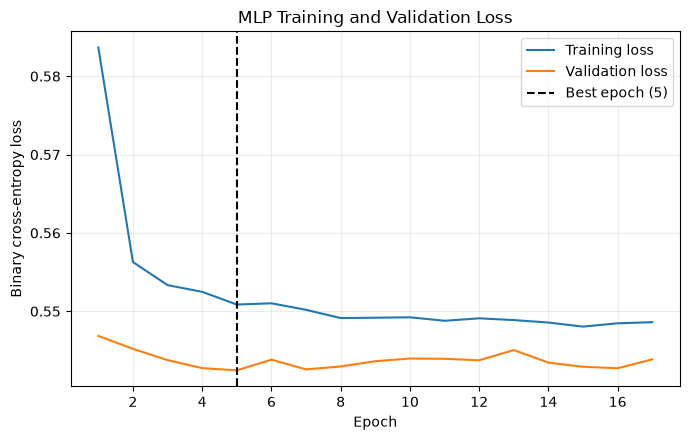

In [36]:
# Create a figure showing how loss changed during training.
loss_figure, loss_axis = plt.subplots(figsize=(7, 4.5))

# Plot training and validation loss for each epoch.
loss_axis.plot(training_history["epoch"], training_history["train_loss"], label="Training loss")
loss_axis.plot(
    training_history["epoch"],
    training_history["validation_loss"],
    label="Validation loss",
)
# Mark the epoch whose model weights were retained.
loss_axis.axvline(
    best_epoch,
    color="black",
    linestyle="--",
    label=f"Best epoch ({best_epoch})",
)
# Add labels and improve readability.
loss_axis.set(
    title="MLP Training and Validation Loss",
    xlabel="Epoch",
    ylabel="Binary cross-entropy loss",
)
loss_axis.grid(alpha=0.25)
loss_axis.legend()
loss_figure.tight_layout()

# Display the figure and release it from memory.
display(loss_figure)
plt.close(loss_figure)

### 13.4 Findings

The figure shows the completed training run and the epoch restored for final
evaluation.

- Training stopped after **17 epochs**; the best checkpoint was epoch **5**, with validation loss **0.542460**.
- Early stopping activated, and the train/validation curves show no severe overfitting.


## 14. Evaluate Baseline Model and Methodology Diagnostics

Threshold decisions use validation probabilities only. The untouched test set is
evaluated after threshold and benchmark decisions are complete.

### 14.1 Metric and Threshold Helpers

AUROC is threshold independent. Precision, recall, F1, accuracy, and balanced
accuracy depend on a threshold; selecting that threshold on test data would
overstate performance.

In [37]:
def evaluate_predictions(
    y_true: pd.Series,
    probabilities: np.ndarray,
    threshold: float,
) -> dict[str, object]:
    """Calculate classification and probability metrics at one threshold."""

    # Keep probabilities away from exactly 0 and 1 for stable loss calculation.
    probabilities = np.clip(np.asarray(probabilities, dtype=float), 1e-7, 1 - 1e-7)
    
    # Convert probabilities into callback predictions using the chosen threshold.
    predictions = (probabilities >= threshold).astype(int)
    
    # Create the confusion matrix and obtain values needed for specificity.
    matrix = confusion_matrix(y_true, predictions, labels=[0, 1])
    true_negative, false_positive, _, _ = matrix.ravel()
    
    # Return threshold-based and probability-based evaluation metrics.
    return {
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "specificity": true_negative / (true_negative + false_positive),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "auroc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
        "binary_cross_entropy": log_loss(y_true, probabilities, labels=[0, 1]),
        "confusion_matrix": matrix.tolist(),
    }


In [38]:

def select_validation_threshold(
    targets: pd.Series,
    probabilities: np.ndarray,
) -> tuple[float, pd.DataFrame]:
    """Select the first threshold with maximum validation F1 on the fixed grid."""
    
    # Test every threshold in the predefined grid.
    threshold_rows = []
    for threshold in THRESHOLD_GRID:
        metrics = evaluate_predictions(targets, probabilities, float(threshold))

        # Store the validation results for comparison.
        threshold_rows.append(
            {
                "threshold": float(threshold),
                "validation_f1": metrics["f1"],
                "validation_precision": metrics["precision"],
                "validation_recall": metrics["recall"],
                "validation_balanced_accuracy": metrics["balanced_accuracy"],
            }
        )
    threshold_performance = pd.DataFrame(threshold_rows)
    
    # Select the first threshold that achieves the highest validation F1.
    selected = threshold_performance.loc[
        threshold_performance["validation_f1"].idxmax()
    ]
    return float(selected["threshold"]), threshold_performance

### 14.2 Fixed Validation-Threshold Selection

The classification threshold is selected using validation data only; the test set is not used during selection. The fixed threshold is **0.32**. Validation precision and recall show the decision trade-off but are not separate headline results.

In [39]:
def predict_probabilities(model: nn.Module, feature_tensor: torch.Tensor) -> np.ndarray:
    """Return sigmoid callback probabilities for one processed feature tensor."""
    
    # Evaluation mode disables training behaviour such as dropout.
    model.eval()

     # Make predictions without calculating gradients.
    with torch.no_grad():
        logits = model(feature_tensor.to(DEVICE))
    
    # Convert the model's raw outputs into probabilities between 0 and 1.
    return torch.sigmoid(logits).cpu().numpy()


In [40]:
# Predict callback probabilities for the validation data.
validation_probabilities = predict_probabilities(neural_network, X_validation_tensor)

# Use validation results to select the threshold with the best F1 score.
SELECTED_THRESHOLD, threshold_performance = select_validation_threshold(
    y_validation,
    validation_probabilities,
)
# Predict callback probabilities for the unseen test data.
test_probabilities = predict_probabilities(neural_network, X_test_tensor)

# Evaluate the test results using the selected and comparison thresholds.
test_metrics_selected = evaluate_predictions(y_test, test_probabilities, SELECTED_THRESHOLD)
test_metrics_050 = evaluate_predictions(y_test, test_probabilities, 0.50)
test_metrics_previous = evaluate_predictions(
    y_test,
    test_probabilities,
    PREVIOUS_FIXED_THRESHOLD,
)
# Record validation metrics at the selected threshold.
validation_metrics_selected = evaluate_predictions(
    y_validation,
    validation_probabilities,
    SELECTED_THRESHOLD,
)
# Convert test probabilities into final class predictions.
test_predictions = (test_probabilities >= SELECTED_THRESHOLD).astype(int)

# Calculate the accuracy of always predicting the most common outcome.
majority_accuracy = max(float(y_test.mean()), 1 - float(y_test.mean()))


In [41]:
# Keep the complete validation and test results for saved diagnostics.
metrics_table = pd.DataFrame(
    [
        {
            "model": "mlp",
            "split": "validation",
            "threshold_decision": "validation_selected",
            "threshold": SELECTED_THRESHOLD,
            **validation_metrics_selected,
        },
        {
            "model": "mlp",
            "split": "test",
            "threshold_decision": "threshold_0_50",
            "threshold": 0.50,
            **test_metrics_050,
        },
        {
            "model": "mlp",
            "split": "test",
            "threshold_decision": "previous_fixed_baseline",
            "threshold": PREVIOUS_FIXED_THRESHOLD,
            **test_metrics_previous,
        },
        {
            "model": "mlp",
            "split": "test",
            "threshold_decision": "validation_selected",
            "threshold": SELECTED_THRESHOLD,
            **test_metrics_selected,
        },
    ]
)
# Display the validation result that selected the fixed threshold.
selected_threshold_row = threshold_performance.loc[
    threshold_performance["threshold"].eq(SELECTED_THRESHOLD),
    ["threshold", "validation_f1", "validation_precision",
     "validation_recall", "validation_balanced_accuracy"],
]
display(selected_threshold_row.style.hide(axis="index").format(precision=4))

threshold,validation_f1,validation_precision,validation_recall,validation_balanced_accuracy
0.3200,0.6382,0.5372,0.7858,0.7016


### 14.3 Validation Threshold Performance

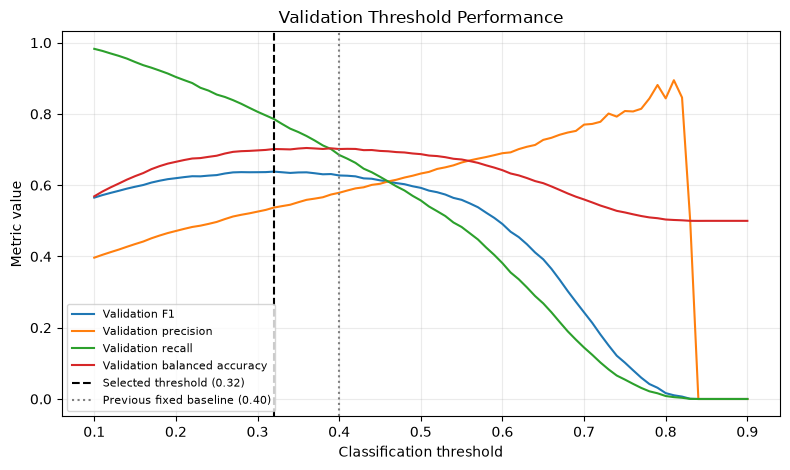

In [42]:
# Plot how each validation metric changes across the tested thresholds.
threshold_figure, threshold_axis = plt.subplots(figsize=(8, 4.8))
for metric_name, label in [
    ("validation_f1", "Validation F1"),
    ("validation_precision", "Validation precision"),
    ("validation_recall", "Validation recall"),
    ("validation_balanced_accuracy", "Validation balanced accuracy"),
]:
    threshold_axis.plot(
        threshold_performance["threshold"],
        threshold_performance[metric_name],
        label=label,
    )
# Mark the selected threshold and the previous fixed threshold.
threshold_axis.axvline(
    SELECTED_THRESHOLD,
    color="black",
    linestyle="--",
    label=f"Selected threshold ({SELECTED_THRESHOLD:.2f})",
)
threshold_axis.axvline(
    PREVIOUS_FIXED_THRESHOLD,
    color="grey",
    linestyle=":",
    label="Previous fixed baseline (0.40)",
)
# Add labels and formatting.
threshold_axis.set(
    title="Validation Threshold Performance",
    xlabel="Classification threshold",
    ylabel="Metric value",
)
threshold_axis.grid(alpha=0.25)
threshold_axis.legend(fontsize=8)
threshold_figure.tight_layout()

# Display and close the figure to avoid duplicate notebook output.
display(threshold_figure)
plt.close(threshold_figure)

# Close an earlier calibration figure if it still exists.
if "calibration_figure" in globals():
    plt.close(calibration_figure)

### 14.4 Primary Baseline Metrics

The headline result evaluates the canonical seed-42 Original Model once on the complete test set. PR-AUC is especially informative because callbacks are the positive class. AUROC measures ranking across all thresholds. F1 balances callback precision and recall, balanced accuracy gives equal importance to callbacks and non-callbacks, and BCE evaluates probability quality.

F1 and balanced accuracy use the fixed validation-selected threshold of **0.32**. PR-AUC, AUROC and BCE are calculated directly from probabilities and do not depend on that threshold.

PR-AUC ↑,AUROC ↑,F1 ↑,Balanced accuracy ↑,BCE ↓
0.6264,0.7686,0.6342,0.6982,0.5456


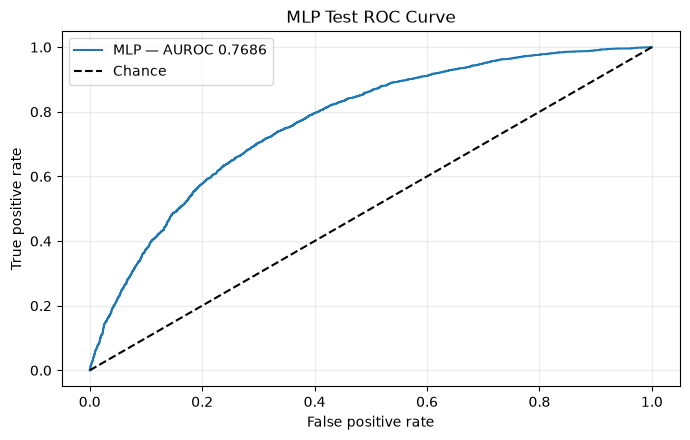

In [43]:
# Present the five headline metrics for the canonical seed-42 test result.
primary_baseline_metrics = pd.DataFrame(
    [
        {
            "PR-AUC ↑": test_metrics_selected["pr_auc"],
            "AUROC ↑": test_metrics_selected["auroc"],
            "F1 ↑": test_metrics_selected["f1"],
            "Balanced accuracy ↑": test_metrics_selected["balanced_accuracy"],
            "BCE ↓": test_metrics_selected["binary_cross_entropy"],
        }
    ]
)
display(primary_baseline_metrics.style.hide(axis="index").format(precision=4))

# Keep the ROC curve as supporting evidence for threshold-independent ranking.
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_probabilities)
roc_figure, roc_axis = plt.subplots(figsize=(7, 4.5))
roc_axis.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"MLP — AUROC {test_metrics_selected['auroc']:.4f}",
)
roc_axis.plot([0, 1], [0, 1], "k--", label="Chance")
roc_axis.set(
    title="MLP Test ROC Curve",
    xlabel="False positive rate",
    ylabel="True positive rate",
)
roc_axis.grid(alpha=0.25)
roc_axis.legend()
roc_figure.tight_layout()
display(roc_figure)
plt.close(roc_figure)

### 14.5 Five-Seed Robustness of the Primary Metrics

The data split remains fixed so this analysis measures model initialisation and
training randomness rather than split variability. Seed 42 is the canonical Original Model and its complete-test result remains the headline baseline result. Seeds 21, 42, 84, 126 and 168 demonstrate stability; the additional seed models are not saved or used in later unlearning comparisons.

In [44]:
# Train and evaluate the MLP using several random seeds.
robustness_rows = []
for seed in ROBUSTNESS_SEEDS:
    
    # Reuse the existing canonical model for seed 42.
    if seed == RANDOM_SEED:
        seed_model = neural_network
        seed_validation_probabilities = validation_probabilities
        seed_test_probabilities = test_probabilities
        seed_summary = canonical_training
    else:
        # Train a new model for each additional seed.
        seed_model, _, seed_summary = train_mlp_for_seed(seed)
        seed_validation_probabilities = predict_probabilities(
            seed_model,
            X_validation_tensor,
        )
        seed_test_probabilities = predict_probabilities(seed_model, X_test_tensor)

    # Select a validation threshold and evaluate the model on the test set.
    seed_threshold, _ = select_validation_threshold(
        y_validation,
        seed_validation_probabilities,
    )
    seed_metrics = evaluate_predictions(y_test, seed_test_probabilities, seed_threshold)
    
    # Store the main result for comparison across seeds.
    robustness_rows.append(
        {
            "seed": seed,
            "selected_threshold": seed_threshold,
            "best_epoch": seed_summary["best_epoch"],
            "stopping_epoch": seed_summary["stopping_epoch"],
            **{
                metric: seed_metrics[metric]
                for metric in [
                    "accuracy",
                    "precision",
                    "recall",
                    "f1",
                    "balanced_accuracy",
                    "auroc",
                    "pr_auc",
                    "binary_cross_entropy",
                ]
            },
        }
    )


In [45]:
# Convert the results from each seed into a table.
mlp_seed_robustness = pd.DataFrame(robustness_rows)

# Summarise the five primary metrics across seeds.
robustness_summary = (
    mlp_seed_robustness[
        ["pr_auc", "auroc", "f1", "balanced_accuracy", "binary_cross_entropy"]
    ]
    .agg(["mean", "std"])
    .T.reset_index(names="metric")
)

# Keep the remaining seed-level classification measures supplementary.
supplementary_robustness = mlp_seed_robustness[
    ["seed", "selected_threshold", "accuracy", "precision", "recall"]
]
display(robustness_summary.style.hide(axis="index").format(precision=4))
display(supplementary_robustness.style.hide(axis="index").format(precision=4))

metric,mean,std
pr_auc,0.6269,0.0012
auroc,0.7692,0.0006
f1,0.6354,0.0011
balanced_accuracy,0.6982,0.0007
binary_cross_entropy,0.5453,0.0004


seed,selected_threshold,accuracy,precision,recall
21,0.2800,0.6697,0.5279,0.8033
42,0.3200,0.6758,0.5350,0.7787
84,0.3000,0.6688,0.5272,0.7990
126,0.3000,0.6740,0.5328,0.7879
168,0.3100,0.6748,0.5338,0.7827


### 14.6 Bootstrap Confidence Intervals

The canonical seed-42 test probabilities are resampled with a fixed bootstrap
seed. Confidence intervals quantify sampling uncertainty; small metric
differences may not be practically distinguishable.

In [46]:
# Treat all audition rounds for the same actor-role pair as one group.
test_cluster_keys = metadata.loc[test_indices, ["actor_id", "role_id"]].astype(str).agg("|".join, axis=1).to_numpy()
unique_clusters = np.unique(test_cluster_keys)

# Use a fixed seed so the bootstrap results can be reproduced.
bootstrap_generator = np.random.default_rng(BOOTSTRAP_SEED)
bootstrap_rows = []

# Repeatedly sample actor-role groups and recalculate the test metrics.
for _ in range(BOOTSTRAP_RESAMPLES):
    sampled_clusters = bootstrap_generator.choice(
        unique_clusters, size=len(unique_clusters), replace=True
    )
    
    # Include every audition round belonging to each sampled group.
    positions = np.concatenate(
        [np.flatnonzero(test_cluster_keys == key) for key in sampled_clusters]
    )
    sampled_targets = y_test.to_numpy()[positions]
    sampled_probabilities = test_probabilities[positions]
    
    # AUROC cannot be calculated if the sample contains only one outcome class.
    if np.unique(sampled_targets).size < 2:
        continue
    
    # Calculate and store the main metrics for this bootstrap sample.
    sampled_metrics = evaluate_predictions(
        sampled_targets, sampled_probabilities, SELECTED_THRESHOLD
    )
    bootstrap_rows.append(
        {
            "auroc": sampled_metrics["auroc"],
            "f1": sampled_metrics["f1"],
            "balanced_accuracy": sampled_metrics["balanced_accuracy"],
        }
    )


In [47]:
# Convert the results from all bootstrap samples into a table.
bootstrap_resamples = pd.DataFrame(bootstrap_rows)

# Record the metrics calculated from the original test set.
point_estimates = {
    "auroc": test_metrics_selected["auroc"],
    "f1": test_metrics_selected["f1"],
    "balanced_accuracy": test_metrics_selected["balanced_accuracy"],
}
# Calculate a 95% confidence interval for each metric.
bootstrap_confidence_intervals = pd.DataFrame(
    [
        {
            "metric": metric,
            "point_estimate": point_estimates[metric],
            "ci_lower": bootstrap_resamples[metric].quantile(0.025),
            "ci_upper": bootstrap_resamples[metric].quantile(0.975),
            "valid_resamples": int(bootstrap_resamples[metric].notna().sum()),
            "bootstrap_method": "actor_role_cluster_bootstrap",
            "unique_test_clusters": len(unique_clusters),
        }
        for metric in point_estimates
    ]
)
# Confirm that the reported F1 estimate matches the original test result.
assert np.isclose(
    bootstrap_confidence_intervals.loc[
        bootstrap_confidence_intervals["metric"].eq("f1"), "point_estimate"
    ].iloc[0],
    test_metrics_selected["f1"],
)
# Display the estimates and their confidence intervals.
display(bootstrap_confidence_intervals.style.hide(axis="index").format(precision=4))


metric,point_estimate,ci_lower,ci_upper,valid_resamples,bootstrap_method,unique_test_clusters
auroc,0.7686,0.7583,0.7790,1000,actor_role_cluster_bootstrap,7921
f1,0.6342,0.6226,0.6466,1000,actor_role_cluster_bootstrap,7921
balanced_accuracy,0.6982,0.6881,0.7079,1000,actor_role_cluster_bootstrap,7921


### 14.7 Calibration Analysis

Calibration checks whether predicted callback probabilities agree with observed callback frequencies. BCE is the primary probability-quality metric; the Brier score is retained as an additional calibration diagnostic.

mean_predicted_probability,observed_callback_rate
0.0703,0.0511
0.1174,0.1111
0.1657,0.1789
0.2269,0.2267
0.3006,0.3189
0.3813,0.3667
0.4671,0.4622
0.5518,0.5389
0.6328,0.6333
0.7225,0.7222


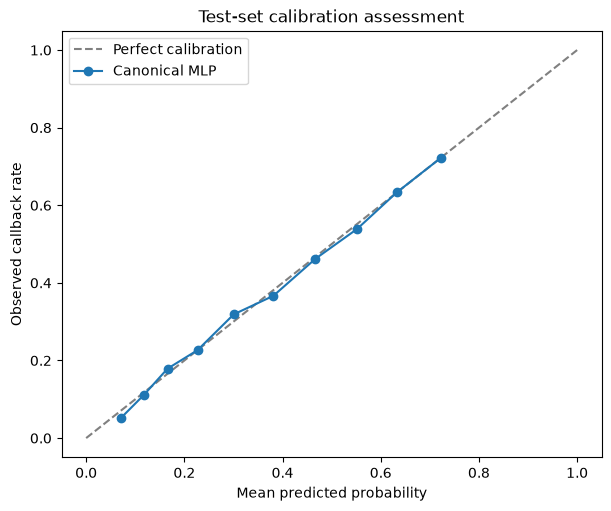

In [48]:
# Group predictions into ten equally sized bins and compare predicted with observed rates.
calibration_observed, calibration_predicted = calibration_curve(
    y_test, test_probabilities, n_bins=10, strategy="quantile"
)
calibration_results = pd.DataFrame(
    {
        "mean_predicted_probability": calibration_predicted,
        "observed_callback_rate": calibration_observed,
    }
)
calibration_figure, calibration_axis = plt.subplots(figsize=(6, 5), constrained_layout=True)
calibration_axis.plot([0, 1], [0, 1], "--", color="grey", label="Perfect calibration")
calibration_axis.plot(calibration_predicted, calibration_observed, marker="o", label="Canonical MLP")
calibration_axis.set(
    xlabel="Mean predicted probability",
    ylabel="Observed callback rate",
    title="Test-set calibration assessment",
)
calibration_axis.legend()
display(calibration_results.style.hide(axis="index").format(precision=4))
display(calibration_figure)
plt.close(calibration_figure)

### 14.8 Supplementary Classification and Calibration Diagnostics

> These are supporting diagnostics rather than headline comparison metrics. Accuracy can be influenced by class distribution; precision and recall are already summarised jointly by F1; specificity contributes to balanced accuracy; and the Brier score overlaps with BCE as a measure of probability quality.

In [49]:
# Present supporting classification and calibration diagnostics separately.
supplementary_diagnostics = pd.DataFrame(
    [
        {"Metric": "Accuracy", "Result": test_metrics_selected["accuracy"],
         "Purpose": "Overall proportion classified correctly"},
        {"Metric": "Precision", "Result": test_metrics_selected["precision"],
         "Purpose": "Proportion of predicted callbacks that were correct"},
        {"Metric": "Recall", "Result": test_metrics_selected["recall"],
         "Purpose": "Proportion of real callbacks identified"},
        {"Metric": "Specificity", "Result": test_metrics_selected["specificity"],
         "Purpose": "Proportion of non-callbacks identified"},
        {"Metric": "Brier score", "Result": test_metrics_selected["brier_score"],
         "Purpose": "Mean squared probability error"},
    ]
)
display(supplementary_diagnostics.style.hide(axis="index").format({"Result": "{:.4f}"}))

Metric,Result,Purpose
Accuracy,0.6758,Overall proportion classified correctly
Precision,0.5350,Proportion of predicted callbacks that were correct
Recall,0.7787,Proportion of real callbacks identified
Specificity,0.6176,Proportion of non-callbacks identified
Brier score,0.1843,Mean squared probability error


### 14.9 Supporting Confusion Matrix and Classification Report

The confusion matrix is supporting evidence rather than a primary metric. It provides the underlying counts used to calculate precision, recall, specificity, F1 and balanced accuracy. The classification report uses the same fixed validation-selected threshold.

              precision    recall  f1-score   support

 No callback     0.8317    0.6176    0.7088      5751
    Callback     0.5350    0.7787    0.6342      3249

    accuracy                         0.6758      9000
   macro avg     0.6833    0.6982    0.6715      9000
weighted avg     0.7246    0.6758    0.6819      9000



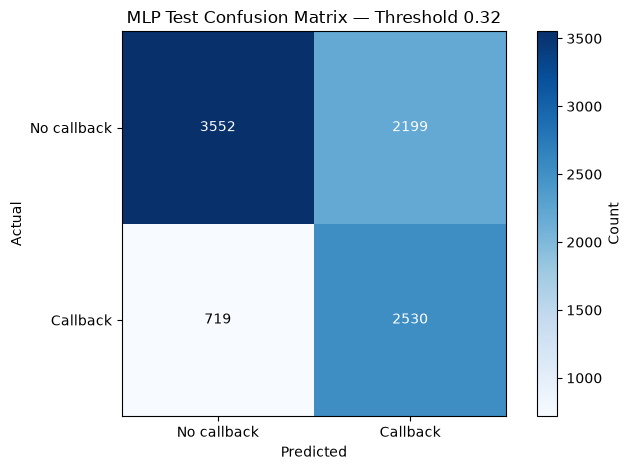

In [50]:
# Show the class-level results at the fixed validation-selected threshold.
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["No callback", "Callback"],
        digits=4,
        zero_division=0,
    )
)

# Display the underlying classification counts.
matrix = np.asarray(test_metrics_selected["confusion_matrix"])
confusion_figure, confusion_axis = plt.subplots(figsize=(7, 4.8))
image = confusion_axis.imshow(matrix, cmap="Blues")
confusion_axis.set(
    title=f"MLP Test Confusion Matrix — Threshold {SELECTED_THRESHOLD:.2f}",
    xlabel="Predicted",
    ylabel="Actual",
    xticks=[0, 1],
    xticklabels=["No callback", "Callback"],
    yticks=[0, 1],
    yticklabels=["No callback", "Callback"],
)
for row in range(2):
    for column in range(2):
        colour = "white" if matrix[row, column] > matrix.max() / 2 else "black"
        confusion_axis.text(column, row, matrix[row, column], ha="center", va="center", color=colour)
confusion_figure.colorbar(image, ax=confusion_axis, label="Count")
confusion_figure.tight_layout()
display(confusion_figure)
plt.close(confusion_figure)

### 14.10 Logistic Regression Benchmark

Logistic regression uses the same split and fitted feature preprocessing as the MLP. Its threshold is also selected solely from validation probabilities; the seed-42 MLP remains the canonical Original Model regardless of benchmark performance.

In [51]:
# Train a simpler logistic regression model for comparison.
logistic_regression = LogisticRegression(
    max_iter=1_000,
    random_state=RANDOM_SEED,
)
logistic_regression.fit(X_train_processed, y_train)

# Select its threshold using validation probabilities only.
logistic_validation_probabilities = logistic_regression.predict_proba(
    X_validation_processed
)[:, 1]
logistic_threshold, logistic_threshold_performance = select_validation_threshold(
    y_validation, logistic_validation_probabilities
)
logistic_test_probabilities = logistic_regression.predict_proba(X_test_processed)[:, 1]
logistic_test_metrics = evaluate_predictions(
    y_test, logistic_test_probabilities, logistic_threshold
)

# Compare the benchmark with the canonical Original Model.
model_comparison = pd.DataFrame(
    [
        {"model": "mlp_canonical_seed_42", "threshold": SELECTED_THRESHOLD,
         **test_metrics_selected},
        {"model": "logistic_regression", "threshold": logistic_threshold,
         **logistic_test_metrics},
    ]
)
display(
    model_comparison.drop(columns="confusion_matrix")
    .style.hide(axis="index").format(precision=4)
)

model,threshold,accuracy,precision,recall,f1,specificity,balanced_accuracy,auroc,pr_auc,brier_score,binary_cross_entropy
mlp_canonical_seed_42,0.3200,0.6758,0.5350,0.7787,0.6342,0.6176,0.6982,0.7686,0.6264,0.1843,0.5456
logistic_regression,0.3000,0.6689,0.5274,0.7975,0.6349,0.5962,0.6969,0.7698,0.6290,0.1840,0.5448


### 14.11 Evaluation Findings

- Validation data alone selected the fixed threshold **0.32** by maximum F1; the test set did not influence threshold selection.
- The canonical seed-42 Original Model was evaluated once on the complete test set, with headline performance reported separately from supporting diagnostics.
- Five-seed results assess stability only; the additional seed models are not used in later unlearning comparisons.


## 15. Save Outputs

The cleaned dataset, canonical model, preprocessor, metrics, figures, exact split arrays, matching audition identities and hash-bearing manifest are saved. No test predictions or forget sets are written.


### 15.1 Create Output Paths

The existing CastMe result and model locations are reused so the baseline has one canonical set of artifacts.

In [52]:
# Define the main folders used to save results and model files.
RESULTS_ROOT = CODE_ROOT / "results" / "CastMe"
MODELS_ROOT = CODE_ROOT / "models" / "castme"
SPLIT_ROOT = RESULTS_ROOT / "configuration" / "baseline_splits"

# Define paths for the saved metrics, tables and configuration manifest.
METRICS_PATH = RESULTS_ROOT / "metrics" / "baseline_metrics.csv"
HISTORY_PATH = RESULTS_ROOT / "tables" / "training_history.csv"
THRESHOLD_SWEEP_PATH = RESULTS_ROOT / "tables" / "threshold_validation_sweep.csv"
MODEL_COMPARISON_PATH = RESULTS_ROOT / "tables" / "model_comparison.csv"
ROBUSTNESS_PATH = RESULTS_ROOT / "tables" / "mlp_seed_robustness.csv"
ROBUSTNESS_SUMMARY_PATH = RESULTS_ROOT / "tables" / "mlp_seed_robustness_summary.csv"
BOOTSTRAP_PATH = RESULTS_ROOT / "tables" / "bootstrap_confidence_intervals.csv"
GROUP_OVERLAP_PATH = RESULTS_ROOT / "tables" / "group_overlap_diagnostics.csv"
CALIBRATION_PATH = RESULTS_ROOT / "tables" / "calibration_results.csv"
BASELINE_MANIFEST_PATH = RESULTS_ROOT / "configuration" / "baseline_manifest.json"

# Define paths for the saved split indices and audition IDs.
SPLIT_INDEX_PATHS = {name: SPLIT_ROOT / f"{name}_indices.npy" for name in ["train", "validation", "test"]}
SPLIT_ID_PATHS = {name: SPLIT_ROOT / f"{name}_audition_ids.npy" for name in ["train", "validation", "test"]}

# Define paths for the saved figures.
FIGURE_PATHS = {
    "confusion": RESULTS_ROOT / "figures" / "confusion_matrix.png",
    "roc": RESULTS_ROOT / "figures" / "roc_curve.png",
    "loss": RESULTS_ROOT / "figures" / "loss_curve.png",
    "threshold": RESULTS_ROOT / "figures" / "threshold_performance.png",
    "calibration": RESULTS_ROOT / "figures" / "calibration_curve.png",
}

# Define paths for the trained model and fitted preprocessor.
MODEL_PATH = MODELS_ROOT / "castme_baseline_mlp.pt"
PREPROCESSOR_PATH = MODELS_ROOT / "castme_preprocessor.joblib"

# Create the required output folders if they do not already exist.
for directory in [METRICS_PATH.parent, HISTORY_PATH.parent, FIGURE_PATHS["loss"].parent,
                  MODELS_ROOT, BASELINE_MANIFEST_PATH.parent, SPLIT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)


### 15.2 Save Metrics and Training History

The comparison metrics and epoch-level loss history are saved in their existing
CSV locations for later reference.

In [53]:
# Save the evaluation results and supporting tables as CSV files.
metrics_table.to_csv(METRICS_PATH, index=False)
training_history.to_csv(HISTORY_PATH, index=False)
threshold_performance.to_csv(THRESHOLD_SWEEP_PATH, index=False)
model_comparison.to_csv(MODEL_COMPARISON_PATH, index=False)
mlp_seed_robustness.to_csv(ROBUSTNESS_PATH, index=False)
robustness_summary.to_csv(ROBUSTNESS_SUMMARY_PATH, index=False)
bootstrap_confidence_intervals.to_csv(BOOTSTRAP_PATH, index=False)
group_overlap_diagnostics.to_csv(GROUP_OVERLAP_PATH, index=False)
calibration_results.to_csv(CALIBRATION_PATH, index=False)

# Save each split's row positions and audition IDs for reuse in later notebooks.
lower_split_indices = {name.lower(): np.asarray(index, dtype=np.int64) for name, index in split_indices.items()}
for name, indices in lower_split_indices.items():

    # Save the original dataframe row positions.
    np.save(SPLIT_INDEX_PATHS[name], indices)
    
    # Save the stable audition IDs belonging to those rows.
    audition_ids = metadata.loc[indices, "audition_id"].astype(str).to_numpy(dtype="U")
    np.save(SPLIT_ID_PATHS[name], audition_ids)


### 15.3 Save Figures

The three existing figures are saved at 300 DPI for readable presentation use.

In [54]:
# Save each figure as a high-resolution PNG with excess whitespace removed.
confusion_figure.savefig(FIGURE_PATHS["confusion"], dpi=300, bbox_inches="tight")
roc_figure.savefig(FIGURE_PATHS["roc"], dpi=300, bbox_inches="tight")
loss_figure.savefig(FIGURE_PATHS["loss"], dpi=300, bbox_inches="tight")
threshold_figure.savefig(FIGURE_PATHS["threshold"], dpi=300, bbox_inches="tight")
calibration_figure.savefig(FIGURE_PATHS["calibration"], dpi=300, bbox_inches="tight")

### 15.4 Save Model and Preprocessor

Checkpoint weights are converted to CPU for portable loading while the existing
metadata is preserved.

In [55]:
# Move the trained weights to the CPU so the model can be loaded on any device.
cpu_state_dict = {name: tensor.detach().cpu().clone() for name, tensor in neural_network.state_dict().items()}

# Move the trained weights to the CPU so the model can be loaded on any device.
checkpoint = {
    "state_dict": cpu_state_dict, "input_dim": len(FEATURE_COLUMNS),
    "feature_columns": FEATURE_COLUMNS,
    "audit_metadata_definitions": {
        "audition_date": "ISO audition date used only for retention-based deletion",
        "withdrawal_requested": "Recorded submission-level withdrawal request used only for deletion construction",
    },
    "excluded_metadata_columns": EXCLUDED_METADATA_COLUMNS,
    "continuous_columns": CONTINUOUS_COLUMNS, "binary_columns": BINARY_COLUMNS,
    "architecture": MODEL_ARCHITECTURE, "training_hyperparameters": TRAINING_HYPERPARAMETERS,
    "seed": RANDOM_SEED, "selected_threshold": SELECTED_THRESHOLD,
    "previous_fixed_threshold": PREVIOUS_FIXED_THRESHOLD,
    "threshold_selection_split": "validation", "threshold_selection_metric": "f1",
    "best_epoch": best_epoch, "best_validation_loss": best_validation_loss,
    "stopping_epoch": stopping_epoch, "raw_csv_sha256": RAW_CSV_SHA256,
    "cleaned_csv_sha256": CLEANED_CSV_SHA256, "runtime_versions": RUNTIME_VERSIONS,
}
# Save the model checkpoint and fitted preprocessing pipeline.
torch.save(checkpoint, MODEL_PATH)
_ = joblib.dump(preprocessor, PREPROCESSOR_PATH)


In [56]:
# Record the location, integrity hash and size of each saved data split.
split_artifacts = {}
for name, indices in lower_split_indices.items():
    split_artifacts[name] = {
        "index_path": str(SPLIT_INDEX_PATHS[name].relative_to(CODE_ROOT)),
        "index_sha256": sha256(SPLIT_INDEX_PATHS[name]),
        "audition_id_path": str(SPLIT_ID_PATHS[name].relative_to(CODE_ROOT)),
        "audition_id_sha256": sha256(SPLIT_ID_PATHS[name]),
        "row_count": len(indices),
        "proportion": len(indices) / len(df_clean),
    }


# Summarise the dataset, model, preprocessing and split configuration.
baseline_manifest = {
    "dataset_description": "Synthetic repeated-round personal audition submissions with audit-only deletion metadata.",
    "row_count": len(df_clean), "audit_metadata_definitions": checkpoint["audit_metadata_definitions"],
    "model_feature_list": FEATURE_COLUMNS, "excluded_metadata_columns": EXCLUDED_METADATA_COLUMNS,
    "target_column": TARGET_COLUMN, "stratification_target": TARGET_COLUMN,
    "split_strategy": "seed-42 two-stage stratified random row split (70/15/15)",
    "split_proportions": {"train": 0.70, "validation": 0.15, "test": 0.15},
    "split_artifacts": split_artifacts, "seed": RANDOM_SEED,
    "fixed_validation_threshold": SELECTED_THRESHOLD, "architecture": MODEL_ARCHITECTURE,
    "preprocessor_path": str(PREPROCESSOR_PATH.relative_to(CODE_ROOT)),
    "preprocessor_hash": sha256(PREPROCESSOR_PATH), "raw_dataset_hash": RAW_CSV_SHA256,
    "processed_dataset_hash": CLEANED_CSV_SHA256, "runtime_environment": RUNTIME_VERSIONS,
}
# Save the manifest as a readable JSON file.
BASELINE_MANIFEST_PATH.write_text(json.dumps(baseline_manifest, indent=2))


3184

### 15.5 Reload and Verify Outputs

Reloading verifies persistence. Raw and cleaned CSV hashes verify that outputs
still correspond to the approved data inputs.

In [57]:
# Reload the saved files to check that they can be used successfully.
saved_checkpoint = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
saved_preprocessor = joblib.load(PREPROCESSOR_PATH)

# Confirm that the saved model configuration matches this notebook.
assert saved_checkpoint["feature_columns"] == FEATURE_COLUMNS
assert saved_checkpoint["excluded_metadata_columns"] == EXCLUDED_METADATA_COLUMNS
assert saved_checkpoint["input_dim"] == len(FEATURE_COLUMNS)
assert saved_checkpoint["raw_csv_sha256"] == RAW_CSV_SHA256
assert saved_checkpoint["cleaned_csv_sha256"] == CLEANED_CSV_SHA256
assert saved_checkpoint["selected_threshold"] == SELECTED_THRESHOLD
assert saved_checkpoint["threshold_selection_split"] == "validation"

# Confirm that the preprocessor preserves the expected feature order.
assert saved_preprocessor.get_feature_names_out().tolist() == (
    CONTINUOUS_COLUMNS + BINARY_COLUMNS
)

# Rebuild the model and load its saved weights.
reloaded_model = CastMeMLP(saved_checkpoint["input_dim"])
reloaded_model.load_state_dict(saved_checkpoint["state_dict"])

# Test the reloaded model on a small batch and check its outputs are valid.
with torch.no_grad():
    reloaded_logits = reloaded_model(X_test_tensor[:8])
assert torch.isfinite(reloaded_logits).all()


In [58]:
# Reload the saved row indices and audition IDs.
loaded_split_indices = {name: np.load(path, allow_pickle=False) for name, path in SPLIT_INDEX_PATHS.items()}
loaded_split_ids = {name: np.load(path, allow_pickle=False) for name, path in SPLIT_ID_PATHS.items()}

# Confirm that the splits have the expected sizes.
assert [len(loaded_split_indices[name]) for name in ["train", "validation", "test"]] == [42_000, 9_000, 9_000]

# Confirm that the reloaded indices match the original splits.
assert all(np.array_equal(loaded_split_indices[name], lower_split_indices[name]) for name in loaded_split_indices)

# Check that the splits do not overlap and include every dataset row.
loaded_sets = {name: set(values.tolist()) for name, values in loaded_split_indices.items()}
assert not loaded_sets["train"] & loaded_sets["validation"]
assert not loaded_sets["train"] & loaded_sets["test"]
assert not loaded_sets["validation"] & loaded_sets["test"]
assert set.union(*loaded_sets.values()) == set(df_clean.index)

# Confirm that each split contains the correct audition IDs and unchanged files.
for name, indices in loaded_split_indices.items():
    expected_ids = metadata.loc[indices, "audition_id"].astype(str).to_numpy(dtype="U")
    assert np.array_equal(loaded_split_ids[name], expected_ids)
    assert sha256(SPLIT_INDEX_PATHS[name]) == baseline_manifest["split_artifacts"][name]["index_sha256"]
    assert sha256(SPLIT_ID_PATHS[name]) == baseline_manifest["split_artifacts"][name]["audition_id_sha256"]

# Confirm that the raw and processed datasets have not changed.
assert sha256(DATA_PATH) == baseline_manifest["raw_dataset_hash"]
assert sha256(PROCESSED_DATA_PATH) == baseline_manifest["processed_dataset_hash"]
print("Exact split indices and audition identities reloaded and verified.")


Exact split indices and audition identities reloaded and verified.


In [59]:
# Reload the main metrics table and check its structure and values.
loaded_metrics = pd.read_csv(METRICS_PATH)
assert loaded_metrics.columns.tolist() == metrics_table.columns.tolist()
assert np.allclose(loaded_metrics["balanced_accuracy"], metrics_table["balanced_accuracy"])

# Reload each supporting table and compare it with the original version.
for saved_path, expected in [
    (THRESHOLD_SWEEP_PATH, threshold_performance), (MODEL_COMPARISON_PATH, model_comparison),
    (ROBUSTNESS_PATH, mlp_seed_robustness), (ROBUSTNESS_SUMMARY_PATH, robustness_summary),
    (BOOTSTRAP_PATH, bootstrap_confidence_intervals), (GROUP_OVERLAP_PATH, group_overlap_diagnostics),
    (CALIBRATION_PATH, calibration_results),
]:
    loaded_table = pd.read_csv(saved_path)
    
    # Confirm that the saved table has the expected columns.
    assert loaded_table.columns.tolist() == expected.columns.tolist()
    
    # Confirm that all saved numerical values match the originals.
    for column in expected.columns:
        if is_numeric_dtype(expected[column]):
            assert np.allclose(loaded_table[column], expected[column], equal_nan=True)


In [60]:
# Confirm that the saved training history matches the original results.
loaded_history = pd.read_csv(HISTORY_PATH)
assert np.allclose(loaded_history.to_numpy(), training_history.to_numpy())

# Confirm that the cleaned dataset remains unchanged and has no split column.
assert df_clean.shape == (60_000, 19) and "split" not in df_clean.columns

# List every output that the baseline notebook is expected to create.
required_outputs = [METRICS_PATH, HISTORY_PATH, THRESHOLD_SWEEP_PATH, MODEL_COMPARISON_PATH,
                    ROBUSTNESS_PATH, ROBUSTNESS_SUMMARY_PATH, BOOTSTRAP_PATH, GROUP_OVERLAP_PATH,
                    *FIGURE_PATHS.values(), MODEL_PATH, PREPROCESSOR_PATH, BASELINE_MANIFEST_PATH,
                    *SPLIT_INDEX_PATHS.values(), *SPLIT_ID_PATHS.values()]

# Confirm that every required output file exists.
assert all(path.is_file() for path in required_outputs)

# Close the figures to release notebook resources.
for figure in [loss_figure, confusion_figure, roc_figure, threshold_figure]:
    plt.close(figure)
if "calibration_figure" in globals():
    plt.close(calibration_figure)

# Confirm that the saved manifest matches the version created in memory.
assert json.loads(BASELINE_MANIFEST_PATH.read_text()) == baseline_manifest
print("Saved canonical artifacts, manifest and diagnostics reloaded successfully.")


Saved canonical artifacts, manifest and diagnostics reloaded successfully.


## 16. Final Results Summary

- The canonical seed-42 Original Model was evaluated on the complete test set.
- Its primary results are reported using PR-AUC, AUROC, F1, balanced accuracy and BCE.
- The decision metrics use the fixed validation-selected threshold of **0.32**.
- The five-seed analysis indicates whether baseline performance is stable.
- Calibration is assessed separately.
- Accuracy, precision, recall, specificity and Brier score are retained as supplementary diagnostics.
- The baseline represents overall model performance and is not divided into deletion scenarios.
